# Pipeline executing Isolation Foerest Outliers and k-NN Imputing of the missing values

In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importing Data

In [2]:
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'

rta_df = pd.read_csv(
    f'{url2}total_df_with_distances.csv')

interventions_data = rta_df[rta_df['Intervention'] == 1]
print('Missing values:\n', interventions_data.isna().sum())

Missing values:
 Mission ID                  0
Latitude                    0
Longitude                   0
Intervention                0
Eventlevel                  0
T3-T0                    1965
EventType                   0
Vector type                80
AED                         0
Ambulance                   0
Mug                         0
PIT                         0
Province                    0
distance_to_aed             0
distance_to_ambulance       0
distance_to_mug             0
distance_to_pit             0
dtype: int64


## 2. Importing custom transformers for outlier removal and missing values imputation

**DataFrameSplitter**

* Splits dataframe in two, one containing NaNs and one without NaNs

**IsolationForestFilter**

* The custom transformer IsolationForestOutlierRemoval allows the Isolation Forest to be integrated into a scikit-learn pipeline by providing both fit and transform methods.
* It removes the outliers detected by the IsolationForest and passes the cleaned data to the next step (like KNN imputation).
* This approach ensures that you can streamline the entire preprocessing workflow, including outlier removal and imputation, in a single pipeline.

**KNNImputerByGroup**

* Splits the data per vector type.
* Imputes missing values based on selected feautures: Latitude, Longitude, distance to specified vector type and T3-T0
* Concatenates groups back together

In [3]:
from CustomTransformer import DataFrameSplitter, IsolationForestFilter, KNNImputerByGroup

## 3. Creating two Pipelines

In [4]:
# set seed for allowing multiple runs with same outcome
np.random.seed(42)

# Defining the Features for Each Group
feature_groups = {
    'Ambulance': ['Latitude', 'Longitude', 'distance_to_ambulance', 'T3-T0'],
    'MUG': ['Latitude', 'Longitude', 'distance_to_mug', 'T3-T0'],
    'PIT': ['Latitude', 'Longitude', 'distance_to_pit', 'T3-T0']
}

# Pipeline for Filtering Inliers
filtering_pipeline = Pipeline(steps=[
    ('splitter', DataFrameSplitter(column='T3-T0')),
    ('isolation_forest', IsolationForestFilter(column='T3-T0'))
])

# Pipeline for Imputation
imputation_pipeline = Pipeline(steps=[
    ('knn_imputer', KNNImputerByGroup(group_column='Vector type', feature_groups=feature_groups))
])


In [5]:
# Process Data through the Pipeline
# Split the DataFrame
without_nan, with_nan = filtering_pipeline.named_steps['splitter'].transform(interventions_data)

# Filter Inliers using Isolation Forest
filtered_data = filtering_pipeline.named_steps['isolation_forest'].fit_transform(without_nan)

# Combine with the rows that had NaN values
combined_data = pd.concat([filtered_data, with_nan], axis=0)

# Reset index
combined_data.reset_index(drop=True, inplace=True)

# Impute Missing Values
final_data = imputation_pipeline.named_steps['knn_imputer'].fit_transform(combined_data)

# Reset index
final_data.reset_index(drop=True, inplace=True)

# Checking for any remaining missing values
print('Missing values:\n', final_data.isna().sum())

Missing values:
 Mission ID               0
Latitude                 0
Longitude                0
Intervention             0
Eventlevel               0
T3-T0                    0
EventType                0
Vector type              0
AED                      0
Ambulance                0
Mug                      0
PIT                      0
Province                 0
distance_to_aed          0
distance_to_ambulance    0
distance_to_mug          0
distance_to_pit          0
dtype: int64


In [6]:
final_data

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit
0,10221520095,51.248480,4.438690,1,1.0,4.238700,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
1,10221520224,51.282730,4.421340,1,1.0,36.619500,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662
2,10221520316,51.178950,4.390240,1,2.0,10.955033,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.178210,2.980275,1.578813,6.097983
3,10221520324,51.205200,4.765860,1,0.0,9.628933,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.489422,5.373831,5.464297,16.218601
4,10221530065,51.062930,4.456930,1,1.0,8.356450,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.166553,2.220918,3.595612,7.666810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11176,40230950287,51.114360,3.993793,1,1.0,10.232500,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,PIT,0,0,0,0,Oost-Vlaanderen,0.739180,1.519044,12.174423,1.509099
11177,40230990536,51.074329,3.716076,1,1.0,9.726667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,PIT,0,0,0,0,Oost-Vlaanderen,0.188502,0.740630,1.437849,16.399882
11178,40231210174,51.098862,3.997875,1,1.0,12.236667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,PIT,0,0,0,0,Oost-Vlaanderen,0.606343,0.297975,10.739445,0.309332
11179,40231390259,51.022870,3.727340,1,1.0,13.690000,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,PIT,0,0,0,0,Oost-Vlaanderen,0.350945,0.295174,0.574860,14.570859


[Text(0.5, 1.0, 'Logscale of Imputed Response Times'),
 Text(0.5, 0, 'Log10(T3-T0)')]

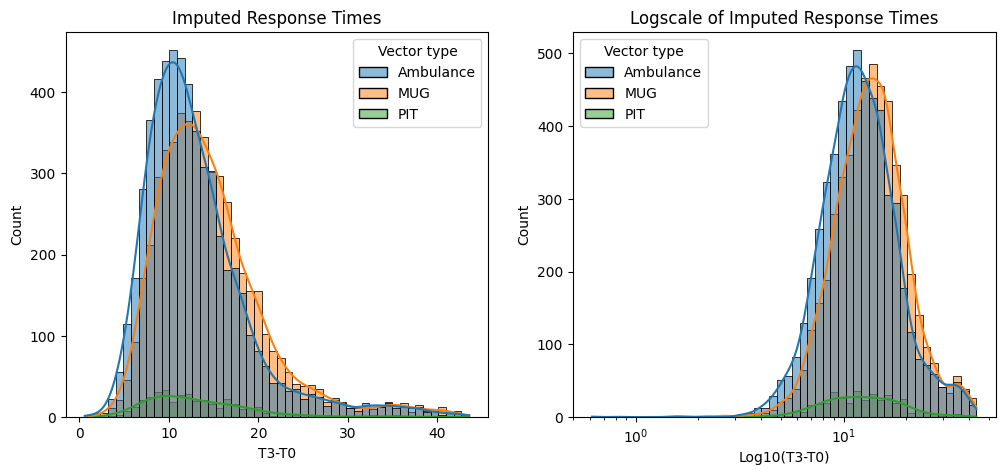

In [7]:
# Plot response times
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=final_data, x='T3-T0', bins=50, log_scale=False, kde=True, hue='Vector type',ax=axes[0]).set(
    title='Imputed Response Times', xlabel='T3-T0') 
sns.histplot(data=final_data, x='T3-T0', bins=50, log_scale=True, kde=True, hue='Vector type',ax=axes[1]).set(
    title='Logscale of Imputed Response Times', xlabel='Log10(T3-T0)') 
# Right-skewed distribution, so log scale was used.